In [ ]:
import pandas as pd

train_path = "cayzn_train.parquet"
test_path = "cayzn_test.parquet"

df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print("Train:")
print(df.info())

print("\nTest:")
print(test_df.info())


Train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 632841 entries, 0 to 632840
Data columns (total 30 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   demand                                   632841 non-null  int64  
 1   departure_date                           632841 non-null  object 
 2   destination_current_public_holiday       632841 non-null  int64  
 3   destination_current_school_holiday       632841 non-null  int64  
 4   destination_days_to_next_public_holiday  632841 non-null  int64  
 5   destination_days_to_next_school_holiday  632841 non-null  int64  
 6   destination_station_name                 632841 non-null  object 
 7   od_destination_time                      632841 non-null  int64  
 8   od_number_of_similar_12_hours            632841 non-null  int64  
 9   od_number_of_similar_2_hours             632841 non-null  int64  
 10  od_number_of_similar_4_ho

# Data Analysis 

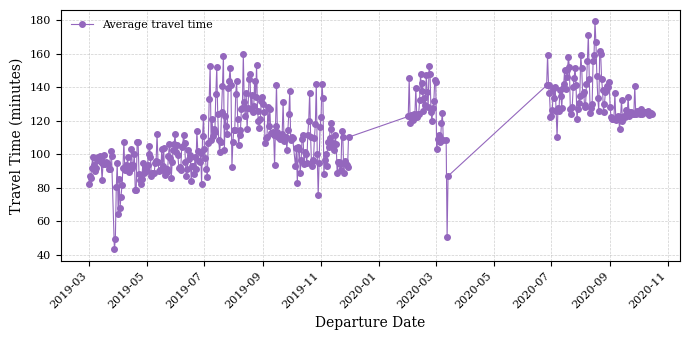

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

#Function to configure IEEE style for plots
def configurar_estilo_ieee():
    """
    Configura os parâmetros de estilo de acordo com as normas IEEE.
    """
    rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "lines.linewidth": 0.8,
        "lines.markersize": 4,
        "savefig.dpi": 300,
        "savefig.format": "pdf",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.6,
        "grid.linewidth": 0.5,
        "figure.figsize": [7, 3.5],
        "legend.loc": "best",
        "legend.frameon": False
    })

configurar_estilo_ieee()

# Convert departure_date column to datetime
df['departure_date'] = pd.to_datetime(df['departure_date'])

# Group by departure_date and calculate the average travel time
avg_travel_time = df.groupby('departure_date')['od_travel_time_minutes'].mean().sort_index()

fig, ax = plt.subplots()

ax.plot(avg_travel_time.index, avg_travel_time.values,
        marker='o', linestyle='-', color='tab:purple', label='Average travel time')

ax.set_xlabel('Departure Date')
ax.set_ylabel('Travel Time (minutes)')

ax.legend()

fig.autofmt_xdate(rotation=45)

plt.tight_layout()

plt.savefig("avg_travel_time_ieee.pdf")

plt.show()

Top 5 Destination Stations:
destination_station_name
bb     260429
cgm    124103
cpe     97867
rb      60705
ag      59702
Name: count, dtype: int64

Top 5 Origin → Destination Pairs:
  origin_station_name destination_station_name   count
4                 cgm                       bb  179872
1                  bb                      cgm  124103
7                  rb                       bb   80557
0                  ag                      cpe   69065
2                  bb                       rb   60705


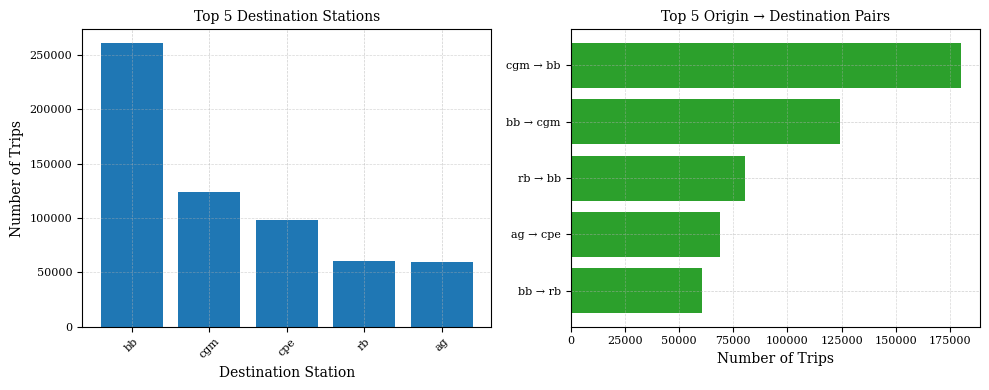

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

configurar_estilo_ieee()

# Ensure datetime format
df['departure_date'] = pd.to_datetime(df['departure_date'])

# 1. Top 5 destination stations
dest_counts = df['destination_station_name'].value_counts()
top5_dest = dest_counts.head(5)

# 2. Count origin→destination pairs and get top 5
od_counts = (
    df
    .groupby(['origin_station_name', 'destination_station_name'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
top5_od = od_counts.head(5)

# 3. Display textual results
print("Top 5 Destination Stations:")
print(top5_dest)

print("\nTop 5 Origin → Destination Pairs:")
print(top5_od)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Top 5 destination stations
ax1.bar(top5_dest.index, top5_dest.values, color='tab:blue')
ax1.set_title('Top 5 Destination Stations')
ax1.set_xlabel('Destination Station')
ax1.set_ylabel('Number of Trips')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax1.tick_params(axis='x', rotation=45)

# Top 5 origin-destination pairs
labels = top5_od.apply(lambda row: f"{row['origin_station_name']} → {row['destination_station_name']}", axis=1)
ax2.barh(labels, top5_od['count'], color='tab:green')
ax2.invert_yaxis()
ax2.set_title('Top 5 Origin → Destination Pairs')
ax2.set_xlabel('Number of Trips')
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("top_routes_ieee.pdf")

plt.show()


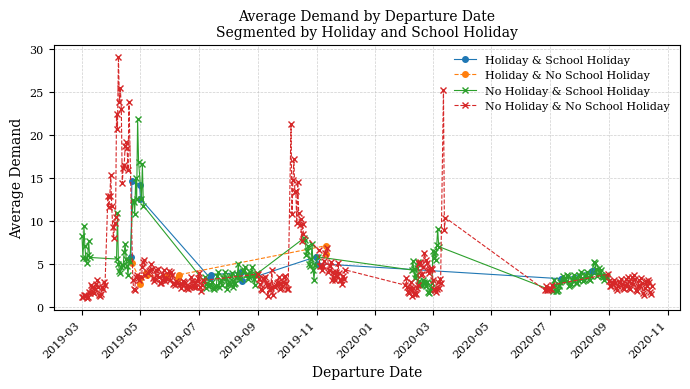

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

configurar_estilo_ieee()

df['departure_date'] = pd.to_datetime(df['departure_date'])
df['destination_current_school_holiday'] = df['destination_current_school_holiday'].astype(bool)

# Define combined filters
cond_holiday_origin_and_school = (
    (df['origin_current_public_holiday'] > 0) &
    (df['destination_current_school_holiday'] == True)
)
cond_holiday_origin_no_school = (
    (df['origin_current_public_holiday'] > 0) &
    (df['destination_current_school_holiday'] == False)
)
cond_no_holiday_origin_school = (
    (df['origin_current_public_holiday'] == 0) &
    (df['destination_current_school_holiday'] == True)
)
cond_no_holiday_origin_no_school = (
    (df['origin_current_public_holiday'] == 0) &
    (df['destination_current_school_holiday'] == False)
)

# Group by departure_date and calculate mean demand
group_1 = df[cond_holiday_origin_and_school].groupby('departure_date')['demand'].mean()
group_2 = df[cond_holiday_origin_no_school].groupby('departure_date')['demand'].mean()
group_3 = df[cond_no_holiday_origin_school].groupby('departure_date')['demand'].mean()
group_4 = df[cond_no_holiday_origin_no_school].groupby('departure_date')['demand'].mean()

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(group_1.index, group_1.values, label='Holiday & School Holiday', marker='o', linestyle='-')
ax.plot(group_2.index, group_2.values, label='Holiday & No School Holiday', marker='o', linestyle='--')
ax.plot(group_3.index, group_3.values, label='No Holiday & School Holiday', marker='x', linestyle='-')
ax.plot(group_4.index, group_4.values, label='No Holiday & No School Holiday', marker='x', linestyle='--')

ax.set_xlabel('Departure Date')
ax.set_ylabel('Average Demand')
ax.set_title('Average Demand by Departure Date\nSegmented by Holiday and School Holiday')
ax.legend()
ax.grid(True)

fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.savefig("demand_by_holiday_ieee.pdf")

plt.show()


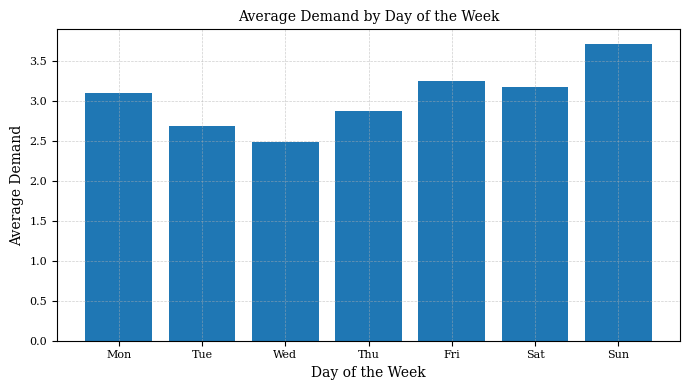

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df['od_origin_weekday'] = df['od_origin_weekday'].astype(int)

weekday_map = {
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}

weekday_demand = df.groupby('od_origin_weekday')['demand'].mean().reset_index()
weekday_demand['weekday_name'] = weekday_demand['od_origin_weekday'].map(weekday_map)

weekday_demand = weekday_demand.sort_values('od_origin_weekday')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(weekday_demand['weekday_name'], weekday_demand['demand'], color='tab:blue')
ax.set_xlabel('Day of the Week')
ax.set_ylabel('Average Demand')
ax.set_title('Average Demand by Day of the Week')
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('demand_by_weekday_ieee.pdf')
plt.show()


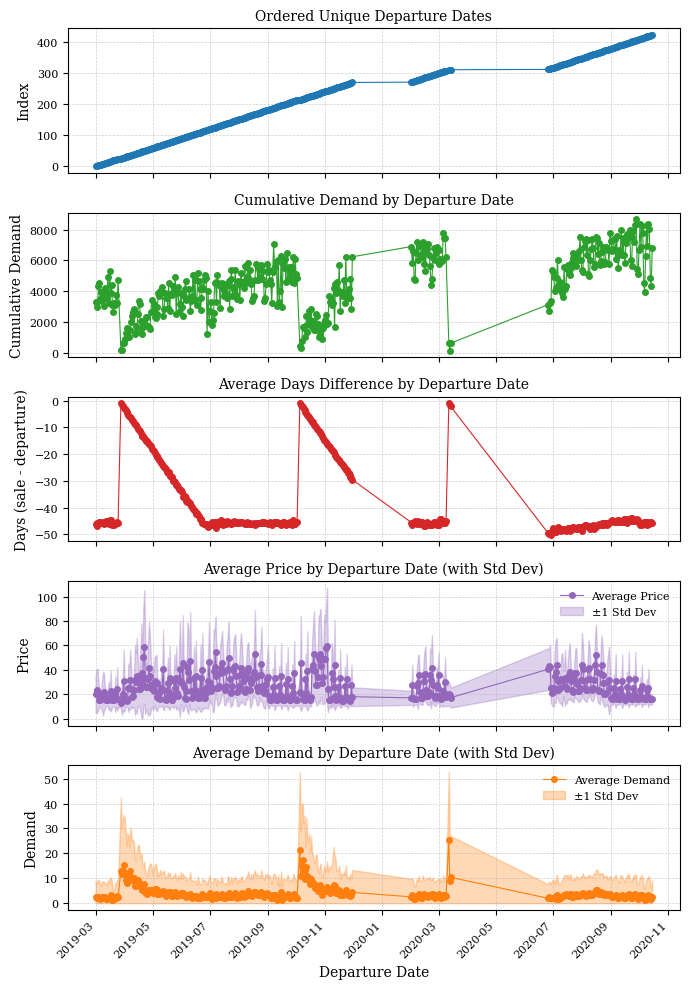

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

configurar_estilo_ieee()

# Convert date columns to datetime
df['departure_date'] = pd.to_datetime(df['departure_date'])
df['sale_date'] = pd.to_datetime(df['sale_date'])

# List of unique departure dates (sorted)
unique_dates = sorted(df['departure_date'].dropna().unique())
y_indices = range(len(unique_dates))

# Cumulative demand by departure date
demand_by_date = df.groupby('departure_date')['demand'].sum().sort_index()

# Average difference between sale_date and departure_date
df['days_between'] = (df['sale_date'] - df['departure_date']).dt.days
avg_days_diff = df.groupby('departure_date')['days_between'].mean().sort_index()

#Price mean and standard deviation by date
price_stats = df.groupby('departure_date')['price'].agg(['mean', 'std']).sort_index()

# Demand mean and standard deviation by date
demand_stats = df.groupby('departure_date')['demand'].agg(['mean', 'std']).sort_index()

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(7, 10), sharex=True)

ax1.plot(unique_dates, y_indices, marker='o', linestyle='-', color='tab:blue')
ax1.set_ylabel('Index')
ax1.set_title('Ordered Unique Departure Dates')
ax1.grid(True)

ax2.plot(demand_by_date.index, demand_by_date.values, marker='o', linestyle='-', color='tab:green')
ax2.set_ylabel('Cumulative Demand')
ax2.set_title('Cumulative Demand by Departure Date')
ax2.grid(True)

ax3.plot(avg_days_diff.index, avg_days_diff.values, marker='o', linestyle='-', color='tab:red')
ax3.set_ylabel('Days (sale - departure)')
ax3.set_title('Average Days Difference by Departure Date')
ax3.grid(True)

lower_price = (price_stats['mean'] - price_stats['std']).clip(lower=0)
upper_price = price_stats['mean'] + price_stats['std']
ax4.plot(price_stats.index, price_stats['mean'], marker='o', linestyle='-', color='tab:purple', label='Average Price')
ax4.fill_between(price_stats.index, lower_price, upper_price,
                 color='tab:purple', alpha=0.3, label='±1 Std Dev')
ax4.set_ylabel('Price')
ax4.set_title('Average Price by Departure Date (with Std Dev)')
ax4.legend()
ax4.grid(True)

# Average demand with standard deviation (no negatives)
lower_demand = (demand_stats['mean'] - demand_stats['std']).clip(lower=0)
upper_demand = demand_stats['mean'] + demand_stats['std']
ax5.plot(demand_stats.index, demand_stats['mean'], marker='o', linestyle='-', color='tab:orange', label='Average Demand')
ax5.fill_between(demand_stats.index, lower_demand, upper_demand,
                 color='tab:orange', alpha=0.3, label='±1 Std Dev')
ax5.set_xlabel('Departure Date')
ax5.set_ylabel('Demand')
ax5.set_title('Average Demand by Departure Date (with Std Dev)')
ax5.legend()
ax5.grid(True)

fig.autofmt_xdate(rotation=45)
plt.tight_layout()

plt.savefig("demand_price_trends_ieee.pdf")

plt.show()


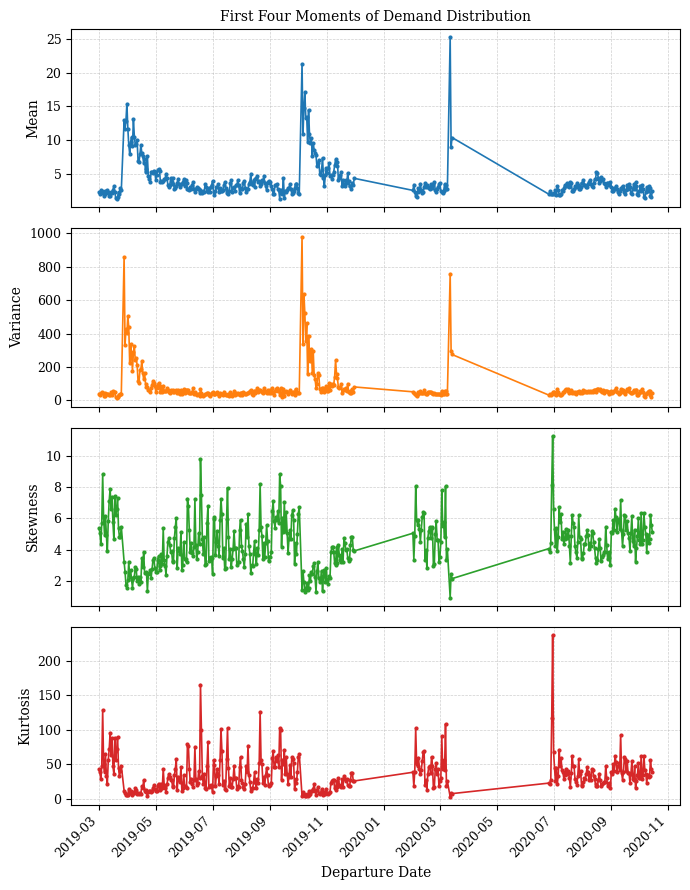

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

df['departure_date'] = pd.to_datetime(df['departure_date'])

# Calcular os momentos para cada data de partida
momentos = []
for date, group in df.groupby('departure_date'):
    demandas = group['demand']
    if len(demandas) > 1:  
        media = demandas.mean()
        variancia = demandas.var()
        assimetria = skew(demandas)
        curtose = kurtosis(demandas, fisher=False)
        momentos.append({
            'departure_date': date,
            'mean': media,
            'variance': variancia,
            'skewness': assimetria,
            'kurtosis': curtose
        })

df_momentos = pd.DataFrame(momentos).sort_values('departure_date')

plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'lines.linewidth': 1.2
})

fig, axs = plt.subplots(4, 1, figsize=(7, 9), sharex=True)

#Média
axs[0].plot(df_momentos['departure_date'], df_momentos['mean'], color='tab:blue', marker='o', markersize=2)
axs[0].set_ylabel('Mean')
axs[0].set_title('First Four Moments of Demand Distribution')

# Variância
axs[1].plot(df_momentos['departure_date'], df_momentos['variance'], color='tab:orange', marker='o', markersize=2)
axs[1].set_ylabel('Variance')

# Assimetria
axs[2].plot(df_momentos['departure_date'], df_momentos['skewness'], color='tab:green', marker='o', markersize=2)
axs[2].set_ylabel('Skewness')

# Curtose
axs[3].plot(df_momentos['departure_date'], df_momentos['kurtosis'], color='tab:red', marker='o', markersize=2)
axs[3].set_ylabel('Kurtosis')
axs[3].set_xlabel('Departure Date')

fig.autofmt_xdate(rotation=45)
plt.tight_layout()

plt.savefig("moments_analysis.pdf")


plt.show()


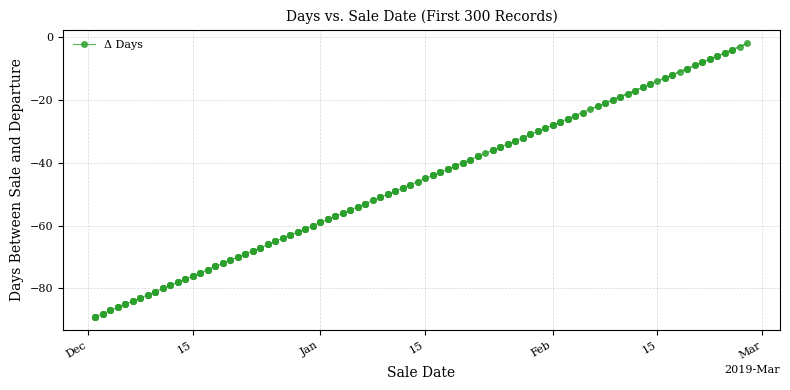

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

configurar_estilo_ieee()  

df['days_between'] = (pd.to_datetime(df['sale_date']) - pd.to_datetime(df['departure_date'])).dt.days

# Select the first 300 records for visualization
x = pd.to_datetime(df['sale_date'].iloc[:300])
y = df['days_between'].iloc[:300]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, y,
        marker='o',
        linestyle='-',
        color='tab:green',
        alpha=0.8,
        label='Δ Days')

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

ax.set_xlabel("Sale Date")
ax.set_ylabel("Days Between Sale and Departure")
ax.set_title("Days vs. Sale Date (First 300 Records)")

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

fig.autofmt_xdate()

plt.tight_layout()

plt.savefig("days_between_ieee.pdf")

plt.show()


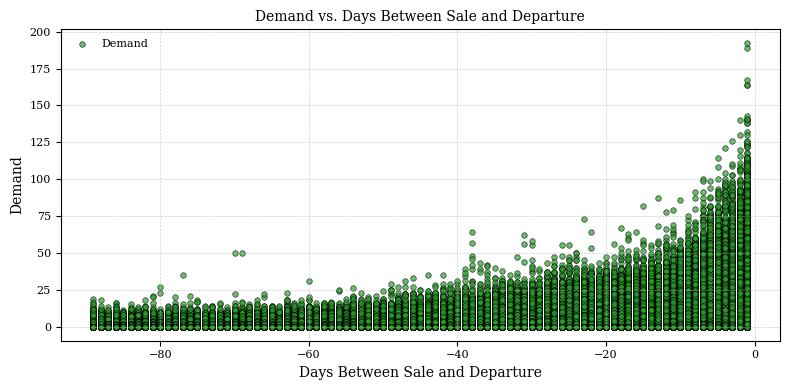

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

configurar_estilo_ieee()

# Compute days_between
df['days_between'] = (
    pd.to_datetime(df['sale_date']) 
    - pd.to_datetime(df['departure_date'])
).dt.days

# Select first 300 records 
x = df['days_between']
y = df['demand']

fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(x, y,
           color='tab:green',
           alpha=0.7,
           edgecolors='black',
           linewidths=0.5,
           label='Demand')

ax.set_xlabel("Days Between Sale and Departure")
ax.set_ylabel("Demand")
ax.set_title("Demand vs. Days Between Sale and Departure")

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()

plt.tight_layout()
plt.savefig("demand_vs_days_ieee.pdf")

plt.show()


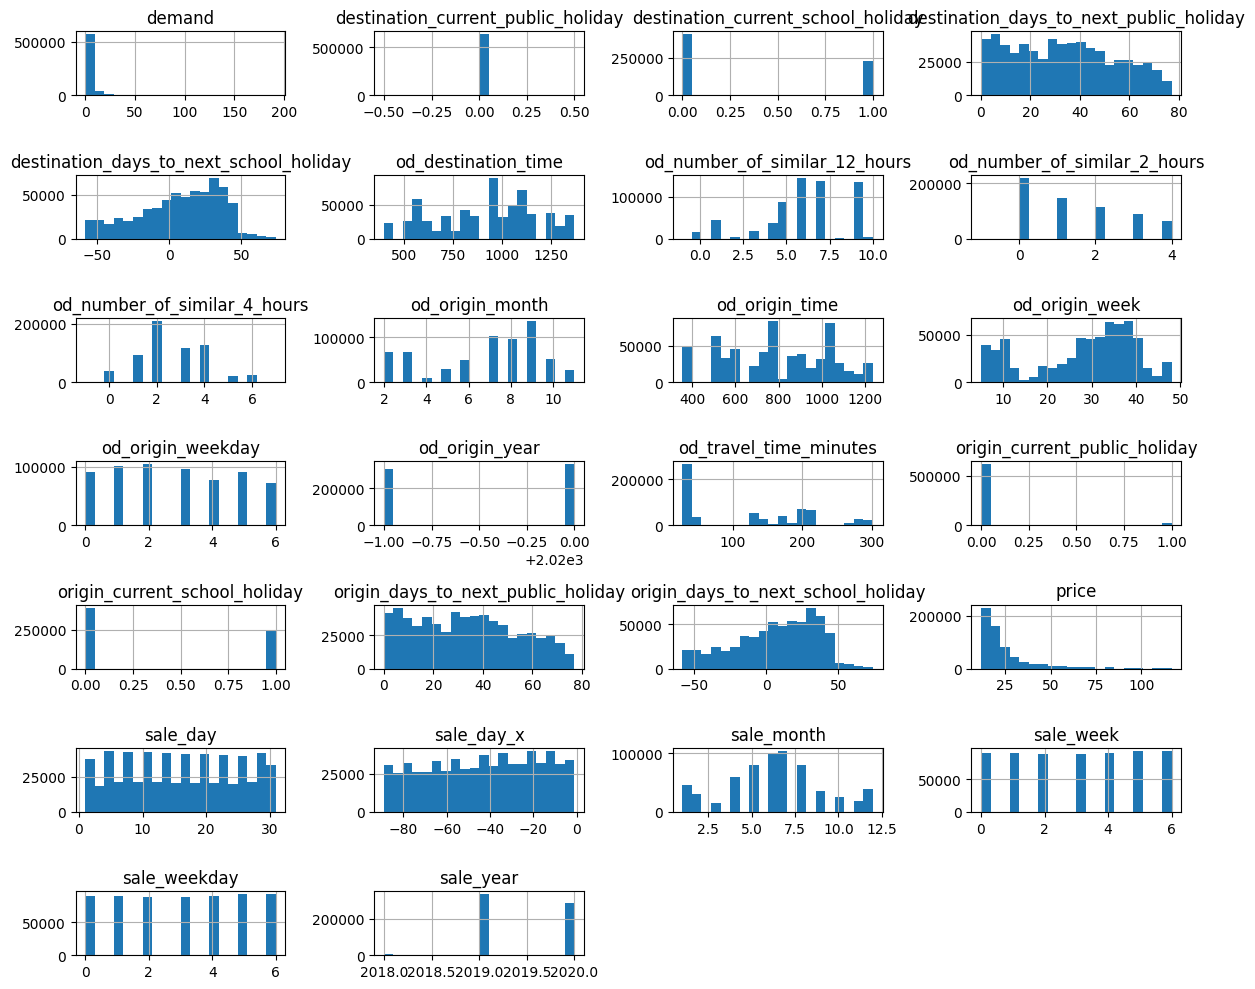

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Seleção e limpeza de variáveis numéricas
df_num = df.select_dtypes(include=[np.number]).copy()
#elimina colunas com >50% de valores faltantes
thresh = len(df_num) * 0.5
df_num = df_num.dropna(axis=1, thresh=thresh)
# Preencher ou remover linhas faltantes
df_num = df_num.dropna(axis=0)

# Histograma 
df_num.hist(bins=20, figsize=(12,10), layout=(int(np.ceil(len(df_num.columns)/4)),4))
plt.tight_layout()
plt.show()


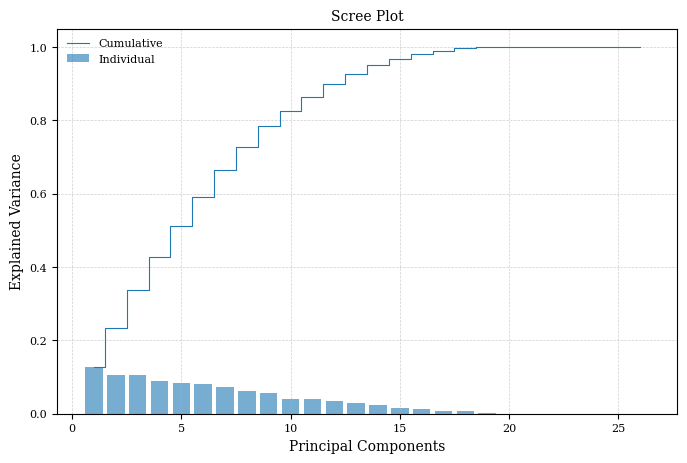


Top 10 variables for PC1:
origin_days_to_next_school_holiday         0.502674
destination_days_to_next_school_holiday    0.494463
origin_current_school_holiday              0.458553
sale_year                                  0.249544
od_origin_year                             0.240907
price                                      0.186020
od_travel_time_minutes                     0.176239
od_number_of_similar_12_hours              0.155187
od_number_of_similar_2_hours               0.135198
od_number_of_similar_4_hours               0.132713
Name: PC1, dtype: float64

Top 10 variables for PC2:
od_number_of_similar_2_hours               0.383761
price                                      0.367335
od_number_of_similar_4_hours               0.362603
od_destination_time                        0.311326
od_origin_time                             0.258763
od_number_of_similar_12_hours              0.245913
demand                                     0.241118
destination_days_to_next_public_holi

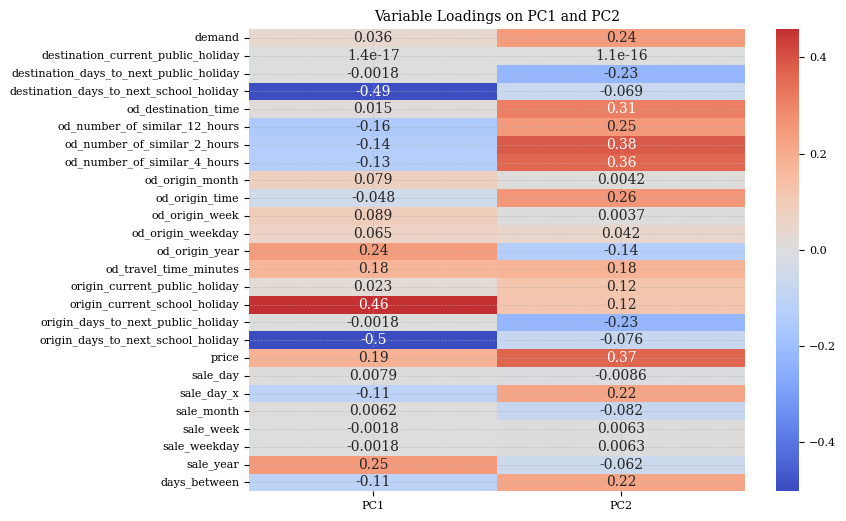

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================
# 1. Filter numeric variables and clean
# ============================
df_num = df.select_dtypes(include=[np.number]).copy()
df_num = df_num.dropna(axis=1, thresh=len(df_num)*0.5)  # remove columns with >50% missing
df_num = df_num.dropna(axis=0)  # remove rows with missing values

# ============================
# 2. Standardization
# ============================
scaler = StandardScaler()
X = scaler.fit_transform(df_num)

# ============================
# 3. Fit PCA
# ============================
pca = PCA()
pca.fit(X)

# ============================
# 4. Explained variance
# ============================
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, label="Individual")
plt.step(range(1, len(cum_var)+1), cum_var, where="mid", label="Cumulative")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.legend()
plt.show()

# ============================
# 5. Loadings Matrix
# ============================
# Loadings = contribution of variables to each component
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_num.columns,
    columns=[f'PC{i+1}' for i in range(len(df_num.columns))]
)

# Show the 10 most influential variables in PC1 and PC2
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(10)
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(10)

print("\nTop 10 variables for PC1:")
print(top_pc1)
print("\nTop 10 variables for PC2:")
print(top_pc2)

# ============================
# 6. Heatmap of loadings (PC1 and PC2)
# ============================
plt.figure(figsize=(8, 6))
sns.heatmap(loadings.iloc[:, :2], annot=True, cmap="coolwarm", center=0)
plt.title("Variable Loadings on PC1 and PC2")
plt.show()


Training the model...

Test Set Results:
MAE: 2.1853
MSE: 18.0722
R²: 0.7005
Mean Error (Bias): -0.5842
Std of Errors: 4.2108


<Figure size 1000x600 with 0 Axes>

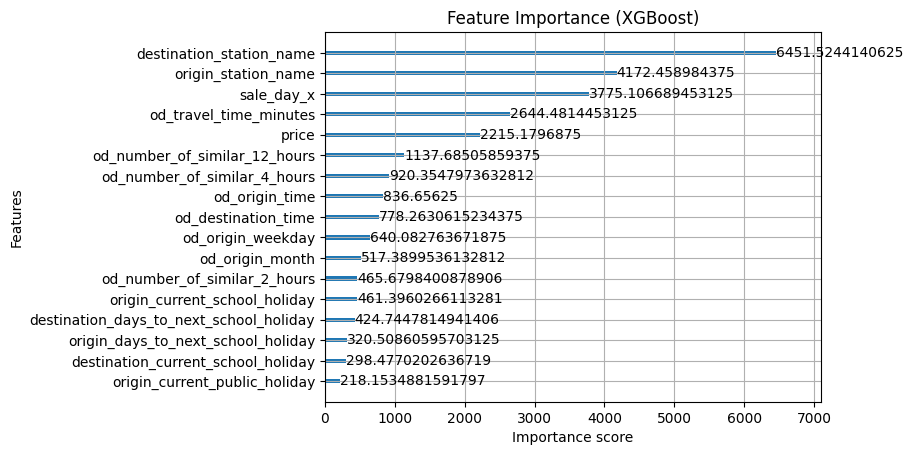

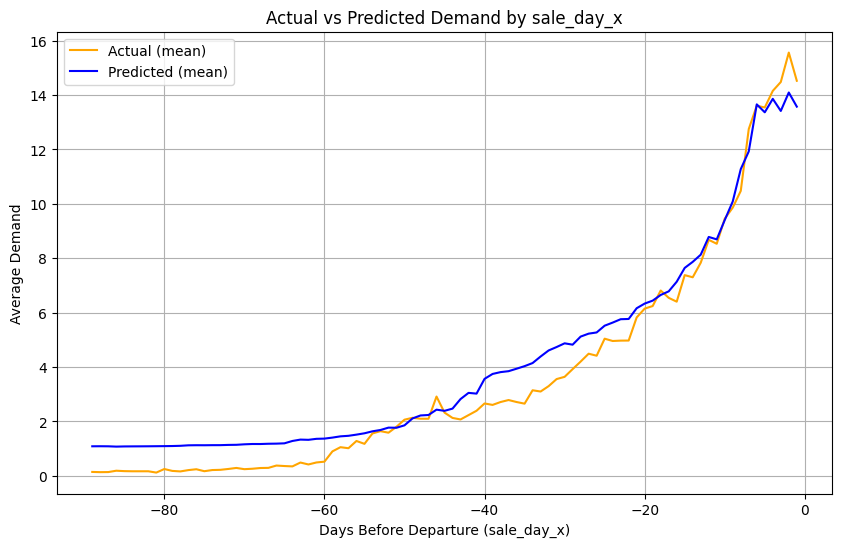

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import random
import numpy as np
import os

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ============================
# 1. Load parquet files
# ============================
path = r"C:\Users\sabri\Documents\mergulhophiphi\data"

train_df = pd.read_parquet(f"{path}\\cayzn_train.parquet")
test_df = pd.read_parquet(f"{path}\\cayzn_test.parquet")

# ============================
# 2. Recommended features
# ============================
features = [
    'price', 'sale_day_x',
    'od_travel_time_minutes',
    'od_number_of_similar_2_hours', 'od_number_of_similar_4_hours', 'od_number_of_similar_12_hours',
    'od_origin_time', 'od_destination_time',
    'origin_current_public_holiday', 'destination_current_public_holiday',
    'origin_current_school_holiday', 'destination_current_school_holiday',
    'origin_days_to_next_school_holiday', 'destination_days_to_next_school_holiday',
    'od_origin_weekday', 'od_origin_month',
    'origin_station_name', 'destination_station_name'
]

target = 'demand'

# ============================
# 3. Preprocessing
# ============================
categorical_cols = ['origin_station_name', 'destination_station_name']
le = LabelEncoder()

for col in categorical_cols:
    all_values = pd.concat([train_df[col], test_df[col]])  
    le.fit(all_values)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# ============================
# 4. Model Training (XGBoost)
# ============================
model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

print("Training the model...")
model.fit(X_train, y_train)

# ============================
# 5. Evaluation on Test Set
# ============================
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nTest Set Results:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

import numpy as np

errors = y_test - y_pred
mean_error = np.mean(errors) 
std_error = np.std(errors)    

print(f"Mean Error (Bias): {mean_error:.4f}")
print(f"Std of Errors: {std_error:.4f}")


# ============================
# 6. Feature Importance
# ============================
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='gain', max_num_features=20)
plt.title("Feature Importance (XGBoost)")
plt.savefig("feature_importance_xgb.jpg")
plt.show()

# ============================
# 7. Error Analysis by sale_day_x (aggregated)
# ============================
test_df['y_pred'] = y_pred
agg = test_df.groupby('sale_day_x').agg({
    'demand': 'mean',
    'y_pred': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(agg['sale_day_x'], agg['demand'], label='Actual (mean)', color='orange')
plt.plot(agg['sale_day_x'], agg['y_pred'], label='Predicted (mean)', color='blue')
plt.xlabel('Days Before Departure (sale_day_x)')
plt.ylabel('Average Demand')
plt.title('Actual vs Predicted Demand by sale_day_x')
plt.legend()
plt.grid()
plt.savefig("demand_by_sale_day.jpg")
plt.show()


In [ ]:
# Baseline 1: sempre prever a média global da demanda
baseline_pred = np.full(len(test_df), train_df['demand'].mean())

mae_baseline = mean_absolute_error(test_df['demand'], baseline_pred)
mse_baseline = mean_squared_error(test_df['demand'], baseline_pred)
r2_baseline = r2_score(test_df['demand'], baseline_pred)

errors_baseline = test_df['demand'] - baseline_pred
mean_error_baseline = errors_baseline.mean()
std_error_baseline = errors_baseline.std()

print("\nBaseline (Global Mean):")
print(f"MAE: {mae_baseline:.4f}")
print(f"MSE: {mse_baseline:.4f}")
print(f"R²: {r2_baseline:.4f}")
print(f"Mean Error (Bias): {mean_error_baseline:.4f}")
print(f"Std of Errors: {std_error_baseline:.4f}")



Baseline (Global Mean):
MAE: 4.3719
MSE: 60.4658
R²: -0.0022
Mean Error (Bias): 0.3629
Std of Errors: 7.7676


In [ ]:
# Baseline 2: média por sale_day_x
mean_by_day = train_df.groupby('sale_day_x')['demand'].mean()
baseline_pred_day = test_df['sale_day_x'].map(mean_by_day)

mae_baseline_day = mean_absolute_error(test_df['demand'], baseline_pred_day)
mse_baseline_day = mean_squared_error(test_df['demand'], baseline_pred_day)
r2_baseline_day = r2_score(test_df['demand'], baseline_pred_day)

errors_baseline_day = test_df['demand'] - baseline_pred_day
mean_error_baseline_day = errors_baseline_day.mean()
std_error_baseline_day = errors_baseline_day.std()

print("\nBaseline (Mean by sale_day_x):")
print(f"MAE: {mae_baseline_day:.4f}")
print(f"MSE: {mse_baseline_day:.4f}")
print(f"R²: {r2_baseline_day:.4f}")
print(f"Mean Error (Bias): {mean_error_baseline_day:.4f}")
print(f"Std of Errors: {std_error_baseline_day:.4f}")


Baseline (Mean by sale_day_x):
MAE: 3.5033
MSE: 47.2050
R²: 0.2176
Mean Error (Bias): 0.6627
Std of Errors: 6.8387



Baseline (Linear Regression with price + sale_day_x):
MAE: 3.6744
MSE: 47.8600
R²: 0.2067
Mean Error (Bias): 0.4065
Std of Errors: 6.9063


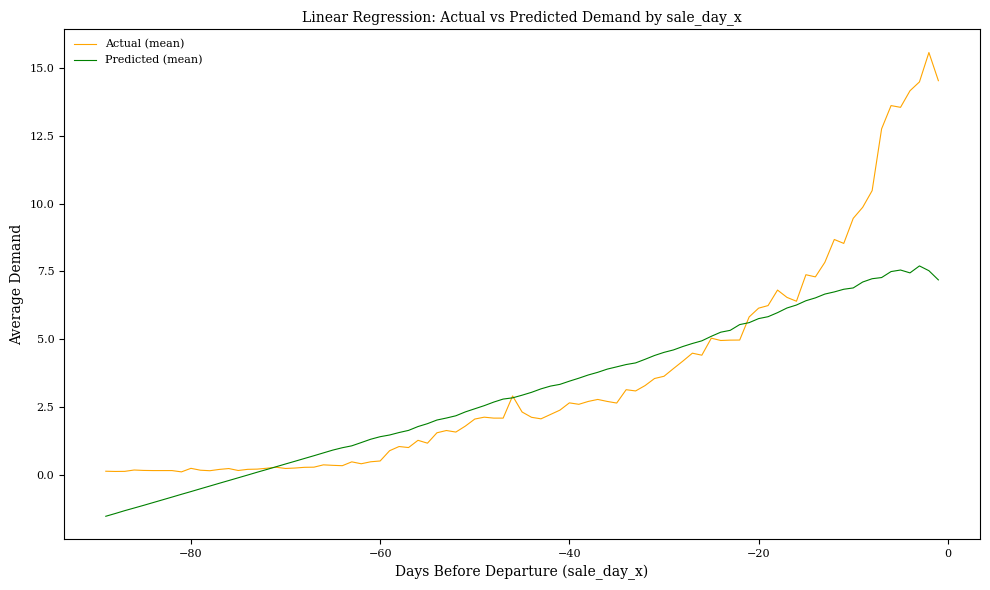

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ==========================
# 1. Features: price e sale_day_x
# ==========================
X_train_lr = train_df[['price', 'sale_day_x']]
y_train_lr = train_df['demand']

X_test_lr = test_df[['price', 'sale_day_x']]
y_test_lr = test_df['demand']

# ==========================
# 2. Treinar modelo Linear Regression
# ==========================
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

# ==========================
# 3. Prever no conjunto de teste
# ==========================
y_pred_lr = lr_model.predict(X_test_lr)

# ==========================
# 4. Métricas
# ==========================
mae_lr = mean_absolute_error(y_test_lr, y_pred_lr)
mse_lr = mean_squared_error(y_test_lr, y_pred_lr)
r2_lr = r2_score(y_test_lr, y_pred_lr)

# Erros individuais
errors_lr = y_test_lr - y_pred_lr
mean_error_lr = errors_lr.mean()
std_error_lr = errors_lr.std()

print("\nBaseline (Linear Regression with price + sale_day_x):")
print(f"MAE: {mae_lr:.4f}")
print(f"MSE: {mse_lr:.4f}")
print(f"R²: {r2_lr:.4f}")
print(f"Mean Error (Bias): {mean_error_lr:.4f}")
print(f"Std of Errors: {std_error_lr:.4f}")

# ==========================
# 5. Gráfico: Média real vs predita por sale_day_x
# ==========================
test_df['y_pred_lr'] = y_pred_lr

agg_lr = test_df.groupby('sale_day_x').agg({
    'demand': 'mean',
    'y_pred_lr': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(agg_lr['sale_day_x'], agg_lr['demand'], label='Actual (mean)', color='orange')
plt.plot(agg_lr['sale_day_x'], agg_lr['y_pred_lr'], label='Predicted (mean)', color='green')
plt.xlabel('Days Before Departure (sale_day_x)')
plt.ylabel('Average Demand')
plt.title('Linear Regression: Actual vs Predicted Demand by sale_day_x')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("linear_regression_demand_by_sale_day.jpg")
plt.show()


Training LightGBM model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 762
[LightGBM] [Info] Number of data points in the train set: 632841, number of used features: 17
[LightGBM] [Info] Start training from score 3.000149

LightGBM Test Set Results:
MAE: 1.9987
MSE: 16.5860
R²: 0.7251
Mean Error (Bias): -0.0591
Std of Errors: 4.0722


<Figure size 1000x600 with 0 Axes>

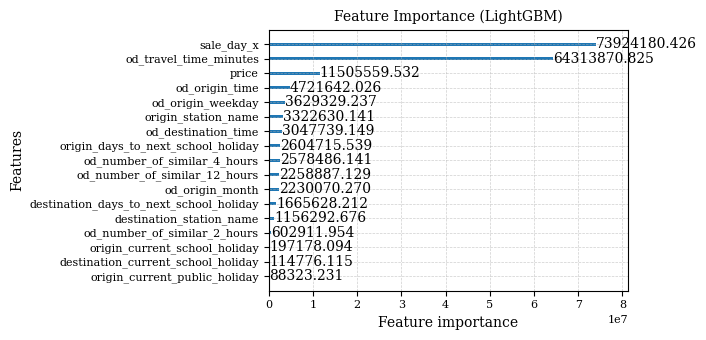

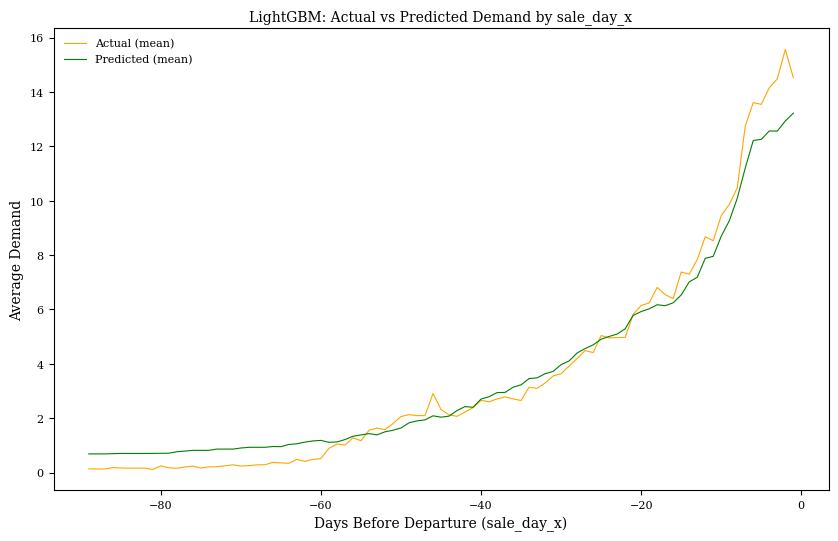

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import random
import os

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ============================
# 1. Load parquet files
# ============================
path = r"C:\Users\sabri\Documents\mergulhophiphi\data"

train_df = pd.read_parquet(f"{path}\\cayzn_train.parquet")
test_df = pd.read_parquet(f"{path}\\cayzn_test.parquet")

# ============================
# 2. Features and Target
# ============================
features = [
    'price', 'sale_day_x',
    'od_travel_time_minutes',
    'od_number_of_similar_2_hours', 'od_number_of_similar_4_hours', 'od_number_of_similar_12_hours',
    'od_origin_time', 'od_destination_time',
    'origin_current_public_holiday', 'destination_current_public_holiday',
    'origin_current_school_holiday', 'destination_current_school_holiday',
    'origin_days_to_next_school_holiday', 'destination_days_to_next_school_holiday',
    'od_origin_weekday', 'od_origin_month',
    'origin_station_name', 'destination_station_name'
]

target = 'demand'

# ============================
# 3. Preprocessing
# ============================
categorical_cols = ['origin_station_name', 'destination_station_name']
encoders = {}  # Dictionary to store encoders for each column

for col in categorical_cols:
    le = LabelEncoder()
    all_values = pd.concat([train_df[col], test_df[col]])
    le.fit(all_values)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])
    encoders[col] = le  # Save the encoder for later decoding

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test_final = test_df[target]  

# ============================
# 4. Model Training (LightGBM)
# ============================
model = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=1  # forçar single-thread para garantir determinismo
)

print("Training LightGBM model...")
model.fit(X_train, y_train)

# ============================
# 5. Evaluation on Test Set
# ============================
y_pred_final = model.predict(X_test)  

mae = mean_absolute_error(y_test_final, y_pred_final)
mse = mean_squared_error(y_test_final, y_pred_final)
r2 = r2_score(y_test_final, y_pred_final)

errors = y_test_final - y_pred_final
mean_error = np.mean(errors)  
std_error = np.std(errors)    

print("\nLightGBM Test Set Results:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Mean Error (Bias): {mean_error:.4f}")
print(f"Std of Errors: {std_error:.4f}")

# ============================
# 6. Feature Importance
# ============================
plt.figure(figsize=(10, 6))
lgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.title("Feature Importance (LightGBM)")
plt.tight_layout()
plt.savefig("feature_importance_lightgbm.jpg")
plt.show()

# ============================
# 7. Error Analysis by sale_day_x
# ============================
test_df['y_pred_final'] = y_pred_final
agg = test_df.groupby('sale_day_x').agg({
    'demand': 'mean',
    'y_pred_final': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(agg['sale_day_x'], agg['demand'], label='Actual (mean)', color='orange')
plt.plot(agg['sale_day_x'], agg['y_pred_final'], label='Predicted (mean)', color='green')
plt.xlabel('Days Before Departure (sale_day_x)')
plt.ylabel('Average Demand')
plt.title('LightGBM: Actual vs Predicted Demand by sale_day_x')
plt.legend()
plt.grid()
plt.savefig("lightgbm_demand_by_sale_day.jpg")
plt.show()


Training LightGBM model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 213
[LightGBM] [Info] Number of data points in the train set: 632841, number of used features: 3
[LightGBM] [Info] Start training from score 3.000149

LightGBM Test Set Results:
MAE: 1.9871
MSE: 20.6773
R²: 0.6573
Mean Error (Bias): 0.3104
Std of Errors: 4.5366


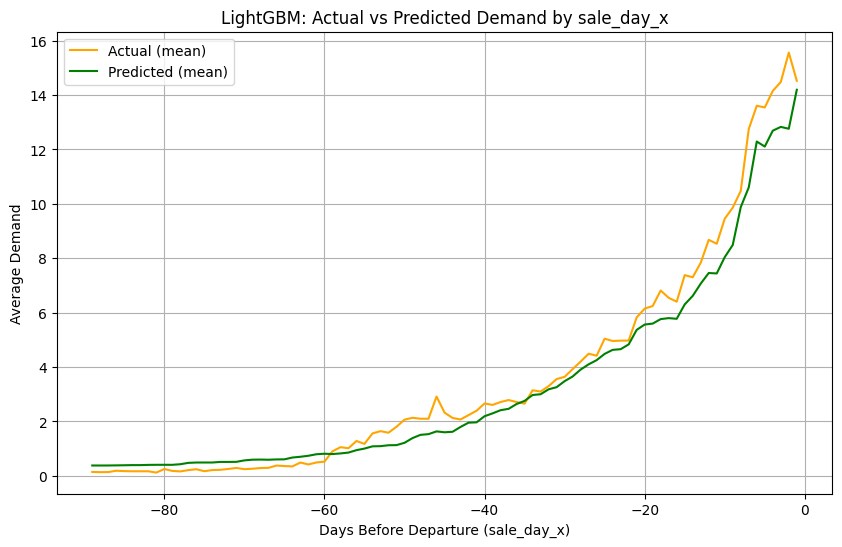

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import random
import os

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ============================
# 1. Load parquet files
# ============================
path = r"C:\Users\sabri\Documents\mergulhophiphi\data"

train_df = pd.read_parquet(f"{path}\\cayzn_train.parquet")
test_df = pd.read_parquet(f"{path}\\cayzn_test.parquet")

# ============================
# 2. Features and Target
# ============================
features = [
    'price', 'sale_day_x',
    'od_travel_time_minutes'
]

target = 'demand'

# ============================
# 3. Preprocessing
# ============================
categorical_cols = ['origin_station_name', 'destination_station_name']
le = LabelEncoder()

for col in categorical_cols:
    all_values = pd.concat([train_df[col], test_df[col]])
    le.fit(all_values)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# ============================
# 4. Model Training (LightGBM)
# ============================
model = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("Training LightGBM model...")
model.fit(X_train, y_train)

# ============================
# 5. Evaluation on Test Set
# ============================
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

errors = y_test - y_pred
mean_error = np.mean(errors)  
std_error = np.std(errors)    

print("\nLightGBM Test Set Results:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Mean Error (Bias): {mean_error:.4f}")
print(f"Std of Errors: {std_error:.4f}")


# ============================
# 7. Error Analysis by sale_day_x
# ============================
test_df['y_pred'] = y_pred
agg = test_df.groupby('sale_day_x').agg({
    'demand': 'mean',
    'y_pred': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(agg['sale_day_x'], agg['demand'], label='Actual (mean)', color='orange')
plt.plot(agg['sale_day_x'], agg['y_pred'], label='Predicted (mean)', color='green')
plt.xlabel('Days Before Departure (sale_day_x)')
plt.ylabel('Average Demand')
plt.title('LightGBM: Actual vs Predicted Demand by sale_day_x')
plt.legend()
plt.grid()
plt.savefig("lightgbm_demand_by_sale_day.jpg")
plt.show()


In [ ]:
(test_df['demand'] == y_test_final).all()

True

   sale_day_x       mae      bias  count
0         -89  0.862098 -0.548235    368
1         -88  0.864135 -0.556387    368
2         -87  0.865650 -0.553339    367
3         -86  0.832563 -0.513235    371
4         -85  0.903258 -0.534893    375


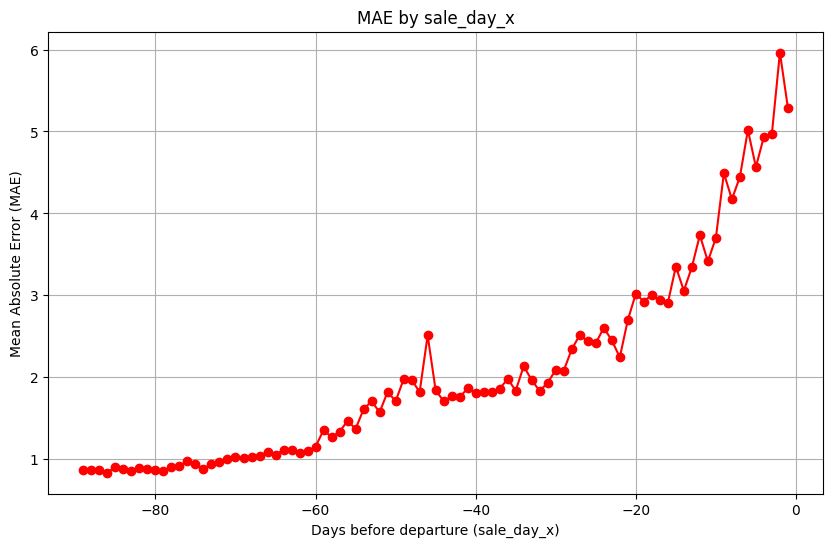

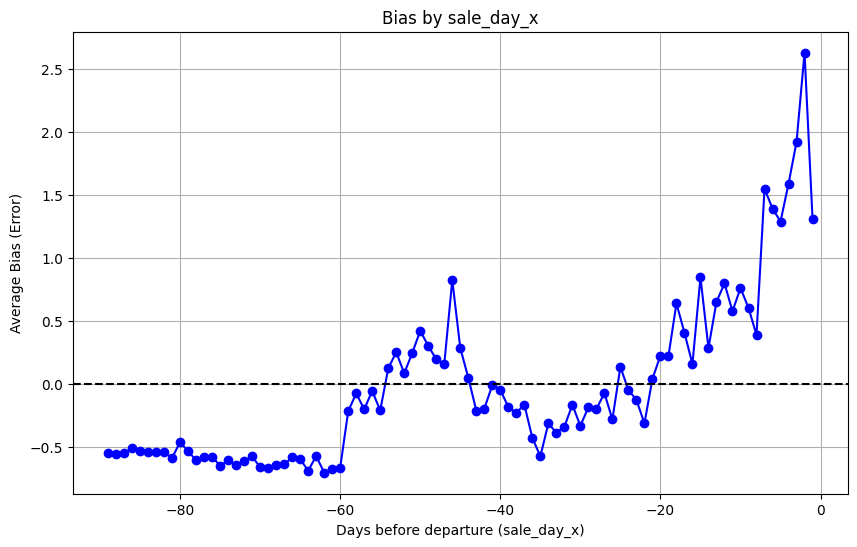

In [ ]:
test_df['y_real'] = y_test_final
test_df['y_pred'] = y_pred_final
test_df['error'] = test_df['y_real'] - test_df['y_pred']
test_df['abs_error'] = test_df['error'].abs()

# Error aggregated by sale_day_x
agg_day_error = test_df.groupby('sale_day_x').agg(
    mae=('abs_error', 'mean'),
    bias=('error', 'mean'),
    count=('y_real', 'count')
).reset_index()

print(agg_day_error.head())

plt.figure(figsize=(10,6))
plt.plot(agg_day_error['sale_day_x'], agg_day_error['mae'], color='red', marker='o')
plt.title('MAE by sale_day_x')
plt.xlabel('Days before departure (sale_day_x)')
plt.ylabel('Mean Absolute Error (MAE)')
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(agg_day_error['sale_day_x'], agg_day_error['bias'], color='blue', marker='o')
plt.axhline(0, color='black', linestyle='--')
plt.title('Bias by sale_day_x')
plt.xlabel('Days before departure (sale_day_x)')
plt.ylabel('Average Bias (Error)')
plt.grid()
plt.show()



Top 5 Destination Stations by MAE:
  destination_station_name       mae      bias  count
0                       ag  3.431719 -0.215800   4404
1                      cpe  3.094844  0.118208   7307
2                       rb  2.760445 -0.223944   2028
3                      cdm  2.564107 -0.139695   2127
4                       bb  1.272023 -0.122143  11906

Top 5 Origin → Destination Pairs by MAE:
     OD_pair       mae      bias  count
0   cpe → ag  3.431719 -0.215800   4404
1   ag → cpe  3.392570  0.029890   5004
2    rb → bb  3.300240 -0.502873   4015
3    bb → rb  2.760445 -0.223944   2028
4  cpe → cdm  2.564107 -0.139695   2127


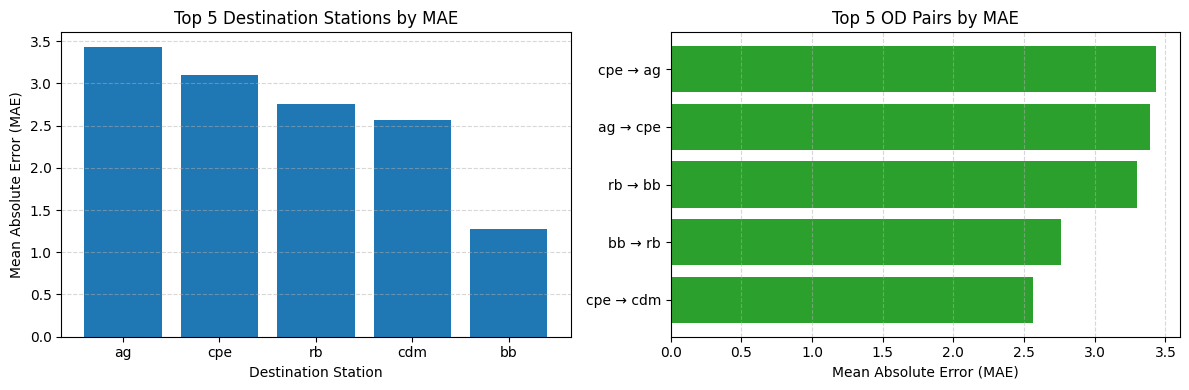

In [ ]:
# Decode the station names back to original strings
for col in categorical_cols:
    test_df[col] = encoders[col].inverse_transform(test_df[col])

test_df['y_real'] = y_test_final
test_df['y_pred'] = y_pred_final
test_df['error'] = test_df['y_real'] - test_df['y_pred']
test_df['abs_error'] = test_df['error'].abs()

import matplotlib.pyplot as plt

test_df['OD_pair'] = test_df['origin_station_name'] + " → " + test_df['destination_station_name']

# Aggregate error by destination station
agg_dest = (
    test_df.groupby('destination_station_name')
    .agg(mae=('abs_error', 'mean'), bias=('error', 'mean'), count=('y_real', 'count'))
    .sort_values('mae', ascending=False)
    .reset_index()
)
top5_dest_mae = agg_dest.head(5)

# Aggregate error by OD (origin → destination)
agg_od = (
    test_df.groupby('OD_pair')
    .agg(mae=('abs_error', 'mean'), bias=('error', 'mean'), count=('y_real', 'count'))
    .sort_values('mae', ascending=False)
    .reset_index()
)
top5_od_mae = agg_od.head(5)


print("\nTop 5 Destination Stations by MAE:")
print(top5_dest_mae)

print("\nTop 5 Origin → Destination Pairs by MAE:")
print(top5_od_mae)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Top 5 destinations by MAE
ax1.bar(top5_dest_mae['destination_station_name'], top5_dest_mae['mae'], color='tab:blue')
ax1.set_title('Top 5 Destination Stations by MAE')
ax1.set_xlabel('Destination Station')
ax1.set_ylabel('Mean Absolute Error (MAE)')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Top 5 OD pairs by MAE
ax2.barh(top5_od_mae['OD_pair'], top5_od_mae['mae'], color='tab:green')
ax2.invert_yaxis()
ax2.set_title('Top 5 OD Pairs by MAE')
ax2.set_xlabel('Mean Absolute Error (MAE)')
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("error_by_routes_ieee.pdf")
plt.show()



In [ ]:
# Percentage of trips by destination station
dest_counts = test_df['destination_station_name'].value_counts()
dest_percentage = (dest_counts / dest_counts.sum()) * 100

print("\nPercentage of trips by destination station:")
print(dest_percentage)

# Check percentage for 'ag' specifically
if 'ag' in dest_percentage.index:
    print(f"\n'ag' represents {dest_percentage['ag']:.2f}% of all trips.")



Percentage of trips by destination station:
destination_station_name
bb     36.560725
cpe    22.438201
cgm    14.718256
ag     13.523722
cdm     6.531552
rb      6.227545
Name: count, dtype: float64

'ag' represents 13.52% of all trips.


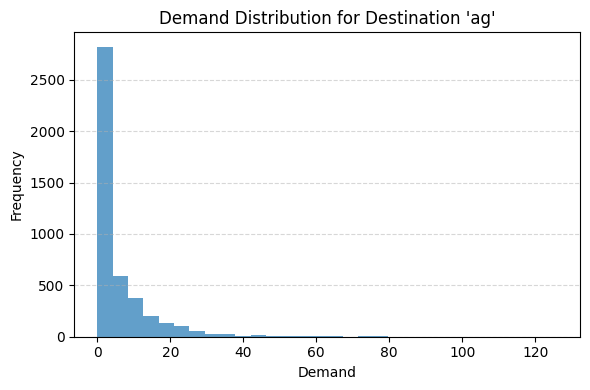


Average demand by destination station:
destination_station_name
ag     5.752725
cpe    5.643629
rb     5.379191
cdm    4.569817
bb     1.841760
cgm    0.080951
Name: y_real, dtype: float64


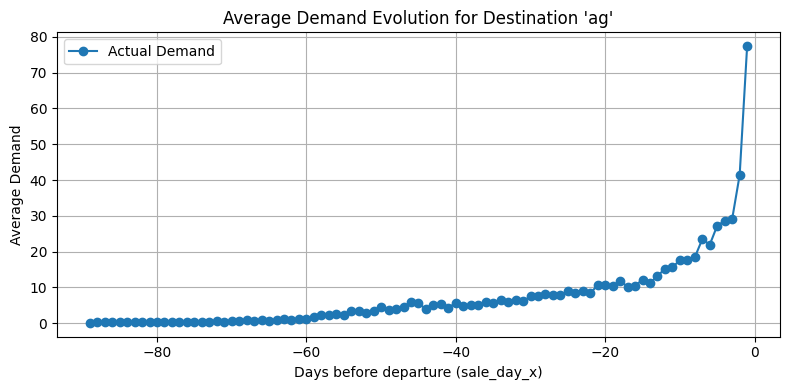

In [ ]:
#ag
df_ag = test_df[test_df['destination_station_name'] == 'ag']


plt.figure(figsize=(6,4))
plt.hist(df_ag['y_real'], bins=30, color='tab:blue', alpha=0.7)
plt.title("Demand Distribution for Destination 'ag'")
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("demand_distribution_ag.pdf")
plt.show()


avg_demand_by_dest = test_df.groupby('destination_station_name')['y_real'].mean().sort_values(ascending=False)
print("\nAverage demand by destination station:")
print(avg_demand_by_dest.head(10))

agg_ag_curve = df_ag.groupby('sale_day_x')['y_real'].mean().reset_index()

plt.figure(figsize=(8,4))
plt.plot(agg_ag_curve['sale_day_x'], agg_ag_curve['y_real'], color='tab:blue', marker='o', label='Actual Demand')
plt.title("Average Demand Evolution for Destination 'ag'")
plt.xlabel('Days before departure (sale_day_x)')
plt.ylabel('Average Demand')
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("booking_curve_ag.pdf")
plt.show()


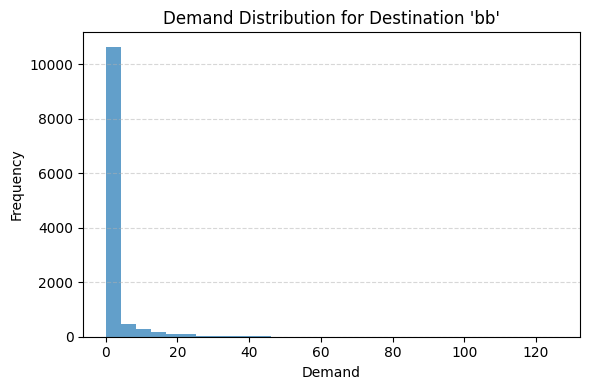


Average demand by destination station:
destination_station_name
ag     5.752725
cpe    5.643629
rb     5.379191
cdm    4.569817
bb     1.841760
cgm    0.080951
Name: y_real, dtype: float64


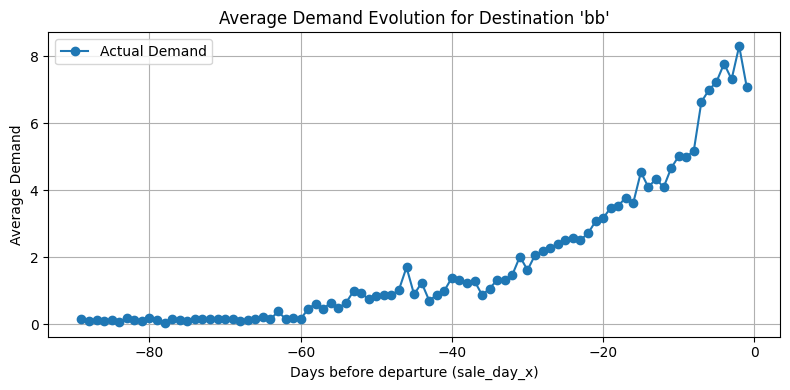

In [ ]:
#bb!
df_ag = test_df[test_df['destination_station_name'] == 'bb']


plt.figure(figsize=(6,4))
plt.hist(df_ag['y_real'], bins=30, color='tab:blue', alpha=0.7)
plt.title("Demand Distribution for Destination 'bb'")
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("demand_distribution_bb.pdf")
plt.show()

avg_demand_by_dest = test_df.groupby('destination_station_name')['y_real'].mean().sort_values(ascending=False)
print("\nAverage demand by destination station:")
print(avg_demand_by_dest.head(10))


agg_ag_curve = df_ag.groupby('sale_day_x')['y_real'].mean().reset_index()

plt.figure(figsize=(8,4))
plt.plot(agg_ag_curve['sale_day_x'], agg_ag_curve['y_real'], color='tab:blue', marker='o', label='Actual Demand')
plt.title("Average Demand Evolution for Destination 'bb'")
plt.xlabel('Days before departure (sale_day_x)')
plt.ylabel('Average Demand')
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("booking_curve_bb.pdf")
plt.show()
